<a href="https://colab.research.google.com/github/Haniakhan702/AneRBC-ANN-and-DL/blob/main/AneRBC_ANN_and_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **DATASET LOADING**

In [ ]:
!pip install -q kaggle

**Upload kaggle.json**

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"haniyyyakhan","key":"fc338944cb7bbfd889c706a2169c9617"}'}

**Configure Kaggle**

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

**Download AneRBC Dataset**

In [ ]:
!kaggle datasets download -d jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images

Dataset URL: https://www.kaggle.com/datasets/jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images
License(s): CC0-1.0
100% 7.41G/7.41G [03:23<00:00, 39.1MB/s]



In [ ]:
!unzip -q anerbc-anemia-diagnosis-using-rbc-images.zip -d dataset

**# Dataset Structure Exploration**

This step examines the folder hierarchy and file organization of the AneRBC dataset to ensure the dataset has been loaded correctly.

In [ ]:
import os

for root, dirs, files in os.walk("dataset"):
    print(root)
    print("Folders:", dirs[:10])
    print("Files:", files[:5])
    print("-"*50)

dataset
Folders: ['AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120']
Files: []
--------------------------------------------------
dataset/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120
Folders: ['AneRBC_dataset']
Files: []
--------------------------------------------------
dataset/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset
Folders: ['AneRBC-II', 'AneRBC-I']
Files: ['readme.txt', 'upload_data_for_training.ipynb']
--------------------------------------------------
dataset/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset/AneRBC-II
Folders: ['Anemic_individuals', 'Healthy_individuals']
Files: []
--------------------------------------------------
dataset/Ane

**Image Count Verification**

This section counts the PNG images present in each dataset folder and verifies the total number of images available for training and evaluation.



In [ ]:
import os

png_count = 0

for root, dirs, files in os.walk("dataset"):
    images = [f for f in files if f.endswith(".png")]

    if len(images) > 0:
        print("\nFOLDER:", root)
        print("Number of PNG images:", len(images))
        print("Sample images:", images[:5])

        png_count += len(images)

print("\nTOTAL PNG IMAGES:", png_count)


FOLDER: dataset/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset/AneRBC-II/Anemic_individuals/RGB_segmented
Number of PNG images: 6000
Sample images: ['0233_08_a.png', '0392_06_a.png', '0438_08_a.png', '0452_06_a.png', '0483_10_a.png']

FOLDER: dataset/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset/AneRBC-II/Anemic_individuals/Original_images
Number of PNG images: 6000
Sample images: ['0233_08_a.png', '0392_06_a.png', '0438_08_a.png', '0452_06_a.png', '0483_10_a.png']

FOLDER: dataset/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset/AneRBC-II/Anemic_individuals/Binary_segmented
Number of PNG images: 6000
Sample images: ['0233_08_a.png', '0392_06_a.png', '0438_08_a.png', '0452_06_a.png', '0483_10_a.png']

FOLDER: datas

**Folder Hierarchy Inspection**

This step displays the dataset folder hierarchy to identify the locations of image directories and verify the organization of the AneRBC dataset.

In [ ]:
import os

for root, dirs, files in os.walk("dataset"):
    if dirs:
        print(root)
        print("Subfolders:", dirs)
        print("-"*50)

dataset
Subfolders: ['AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120']
--------------------------------------------------
dataset/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120
Subfolders: ['AneRBC_dataset']
--------------------------------------------------
dataset/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset
Subfolders: ['AneRBC-II', 'AneRBC-I']
--------------------------------------------------
dataset/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset/AneRBC-II
Subfolders: ['Anemic_individuals', 'Healthy_individuals']
--------------------------------------------------
dataset/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using 

**Dataset Directory Structure Analysis**

This section analyzes the directory structure of the AneRBC dataset by listing all available folders and subfolders. The objective is to identify the locations of healthy and anemic RBC image categories and verify that the dataset is organized correctly for subsequent preprocessing and model development.

In [ ]:
import os

for root, dirs, files in os.walk("dataset"):
    if len(dirs) > 0:
        print(root)
        print(dirs)
        print("="*60)

dataset
['AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120']
dataset/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120
['AneRBC_dataset']
dataset/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset
['AneRBC-II', 'AneRBC-I']
dataset/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset/AneRBC-II
['Anemic_individuals', 'Healthy_individuals']
dataset/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset/AneRBC-II/Anemic_individuals
['Morphology_reports', 'RGB_segmented', 'Original_images', 'CBC_reports', 'Binary_segmented']
dataset/AneRBC dataset a benchmark dataset for computer-aided anemi

**RBC Image Directory Verification**

This step locates the folders containing RBC images and calculates the total number of images available in the dataset.

In [ ]:
import os

png_total = 0

for root, dirs, files in os.walk("dataset"):
    png_files = [f for f in files if f.endswith(".png")]

    if len(png_files) > 100:
        print("IMAGE FOLDER FOUND:")
        print(root)
        print("Images:", len(png_files))
        print()

        png_total += len(png_files)

print("Total images:", png_total)

IMAGE FOLDER FOUND:
dataset/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset/AneRBC-II/Anemic_individuals/RGB_segmented
Images: 6000

IMAGE FOLDER FOUND:
dataset/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset/AneRBC-II/Anemic_individuals/Original_images
Images: 6000

IMAGE FOLDER FOUND:
dataset/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset/AneRBC-II/Anemic_individuals/Binary_segmented
Images: 6000

IMAGE FOLDER FOUND:
dataset/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset/AneRBC-II/Healthy_individuals/RGB_segmented
Images: 6000

IMAGE FOLDER FOUND:
dataset/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis

# **TASK 1: DATA PREPARATION AND VALIDATION**

**Import Libraries**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

**Dataset Paths**

In [ ]:
base_path = "dataset/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset/AneRBC-I"

healthy_path = os.path.join(
    base_path,
    "Healthy_individuals",
    "Original_images"
)

anemic_path = os.path.join(
    base_path,
    "Anemic_individuals",
    "Original_images"
)

print("Healthy Path Exists:", os.path.exists(healthy_path))
print("Anemic Path Exists:", os.path.exists(anemic_path))

Healthy Path Exists: True
Anemic Path Exists: True


**Load Image Paths and Labels**

In [ ]:
image_paths = []
labels = []

for img in os.listdir(healthy_path):
    if img.endswith(".png"):
        image_paths.append(
            os.path.join(healthy_path, img)
        )
        labels.append("Healthy")

for img in os.listdir(anemic_path):
    if img.endswith(".png"):
        image_paths.append(
            os.path.join(anemic_path, img)
        )
        labels.append("Anemic")

print("Total Images:", len(image_paths))
print("Healthy Images:", labels.count("Healthy"))
print("Anemic Images:", labels.count("Anemic"))

Total Images: 1000
Healthy Images: 500
Anemic Images: 500


**Check Corrupted Images**

In [ ]:
corrupted = []

for path in image_paths:
    try:
        img = Image.open(path)
        img.verify()
    except:
        corrupted.append(path)

print("Corrupted Images:", len(corrupted))

Corrupted Images: 0


**Label Encoding**

In [ ]:
encoder = LabelEncoder()

encoded_labels = encoder.fit_transform(labels)

print("Classes:", encoder.classes_)

Classes: ['Anemic' 'Healthy']


**Train Validation Test Split**

In [ ]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    encoded_labels,
    test_size=0.30,
    stratify=encoded_labels,
    random_state=42
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

Train: 700
Validation: 150
Test: 150


**Image Transformations**

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

**Custom Dataset Class**

In [ ]:
class RBCDataset(Dataset):

    def __init__(
        self,
        image_paths,
        labels,
        transform=None
    ):

        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        image = Image.open(
            self.image_paths[idx]
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]

        return image, label

**Create Dataset Objects**

In [ ]:
train_dataset = RBCDataset(
    train_paths,
    train_labels,
    train_transform
)

val_dataset = RBCDataset(
    val_paths,
    val_labels,
    test_transform
)

test_dataset = RBCDataset(
    test_paths,
    test_labels,
    test_transform
)

**CREATE DATALOADERS**

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)

print("Task 1 Completed Successfully")

Task 1 Completed Successfully


**Verify DataLoader**

In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(labels[:10])

torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor([0, 0, 0, 1, 0, 1, 0, 1, 0, 1])


## **TASK 2: BUILD CUSTOM CNN MODELS**

**Import Deep Learning Libraries**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)

Using Device: cpu


**Create CNN-3 Architecture**

In [ ]:
class CNN3(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128*28*28,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(
                256,
                2
            )
        )

    def forward(self,x):

        x = self.features(x)

        x = self.classifier(x)

        return x

**Create Model**

In [ ]:
cnn3 = CNN3().to(device)

print(cnn3)

CNN3(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p

**Define Loss and Optimizer**

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    cnn3.parameters(),
    lr=0.001
)

**Training Function**

In [ ]:
def train_model(model, train_loader, optimizer, criterion, epochs=15):

    losses = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)

        losses.append(epoch_loss)

        print(f"Epoch {epoch+1}/{epochs} Loss: {epoch_loss:.4f}")

    return losses

**Train CNN-3**

In [ ]:
cnn3 = CNN3().to(device)

optimizer = optim.Adam(
    cnn3.parameters(),
    lr=0.0005
)

cnn3_losses = train_model(
    cnn3,
    train_loader,
    epochs=15
)

Epoch 1/15 Loss: 4.9530
Epoch 2/15 Loss: 1.1230
Epoch 3/15 Loss: 0.7065
Epoch 4/15 Loss: 0.6920
Epoch 5/15 Loss: 0.6887
Epoch 6/15 Loss: 0.6939
Epoch 7/15 Loss: 0.6887
Epoch 8/15 Loss: 0.6882
Epoch 9/15 Loss: 0.6909
Epoch 10/15 Loss: 0.6834
Epoch 11/15 Loss: 0.6866
Epoch 12/15 Loss: 0.6850
Epoch 13/15 Loss: 0.6817
Epoch 14/15 Loss: 0.6795
Epoch 15/15 Loss: 0.6863


**Evaluation Function**

In [ ]:
def evaluate_model(
    model,
    test_loader
):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            _, preds = torch.max(
                outputs,
                1
            )

            y_true.extend(
                labels.numpy()
            )

            y_pred.extend(
                preds.cpu().numpy()
            )

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

    print(
        "Accuracy:",
        accuracy_score(
            y_true,
            y_pred
        )
    )

    print(
        "Precision:",
        precision_score(
            y_true,
            y_pred
        )
    )

    print(
        "Recall:",
        recall_score(
            y_true,
            y_pred
        )
    )

    print(
        "F1 Score:",
        f1_score(
            y_true,
            y_pred
        )
    )

    return y_true, y_pred

**Evaluate CNN-3**

In [ ]:
y_true_3, y_pred_3 = evaluate_model(
    cnn3,
    test_loader
)

              precision    recall  f1-score   support

           0       0.54      0.92      0.68        75
           1       0.73      0.21      0.33        75

    accuracy                           0.57       150
   macro avg       0.63      0.57      0.50       150
weighted avg       0.63      0.57      0.50       150

Accuracy: 0.5666666666666667
Precision: 0.7272727272727273
Recall: 0.21333333333333335
F1 Score: 0.32989690721649484


**Confusion Matrix for CNN3**

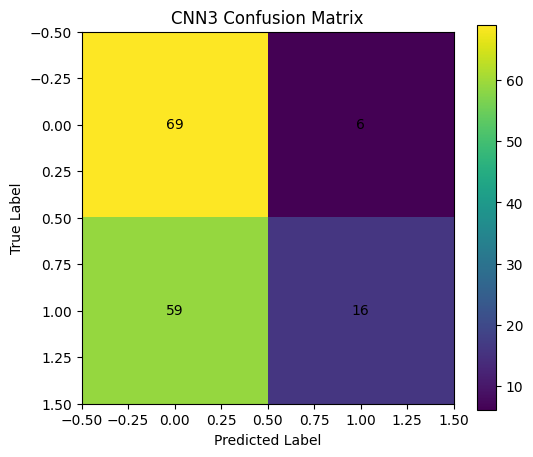

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true_3, y_pred_3)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title("CNN3 Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha="center", va="center")

plt.savefig("CNN3_Confusion_Matrix.png")

plt.show()

**Learning Curve for CNN3**

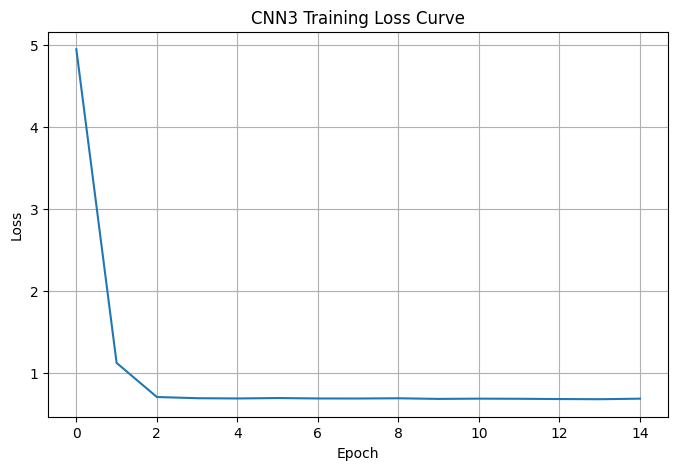

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(cnn3_losses)

plt.title("CNN3 Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.savefig("CNN3_Learning_Curve.png")

plt.show()

**CNN4 Architecture**

In [ ]:
class CNN4(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                256*14*14,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(
                256,
                2
            )
        )

    def forward(self,x):

        x = self.features(x)

        x = self.classifier(x)

        return x

**Create CNN4 Model**

In [ ]:
cnn4 = CNN4().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    cnn4.parameters(),
    lr=0.0005
)

**TRAIN CNN-4**

In [ ]:
cnn4_losses = train_model(
    cnn4,
    train_loader,
    optimizer,
    criterion,
    epochs=15
)

Epoch 1/15 Loss: 4.2211
Epoch 2/15 Loss: 0.9715
Epoch 3/15 Loss: 0.7074
Epoch 4/15 Loss: 0.6889
Epoch 5/15 Loss: 0.6896
Epoch 6/15 Loss: 0.6928
Epoch 7/15 Loss: 0.6917
Epoch 8/15 Loss: 0.6842
Epoch 9/15 Loss: 0.6912
Epoch 10/15 Loss: 0.6834
Epoch 11/15 Loss: 0.6759
Epoch 12/15 Loss: 0.6791
Epoch 13/15 Loss: 0.6866
Epoch 14/15 Loss: 0.6742
Epoch 15/15 Loss: 0.6683


**Evaluate CNN4**

In [ ]:
y_true_4, y_pred_4 = evaluate_model(
    cnn4,
    test_loader
)

              precision    recall  f1-score   support

           0       0.56      0.92      0.69        75
           1       0.77      0.27      0.40        75

    accuracy                           0.59       150
   macro avg       0.66      0.59      0.54       150
weighted avg       0.66      0.59      0.54       150

Accuracy: 0.5933333333333334
Precision: 0.7692307692307693
Recall: 0.26666666666666666
F1 Score: 0.39603960396039606


**CNN4 Confusion Matrix**

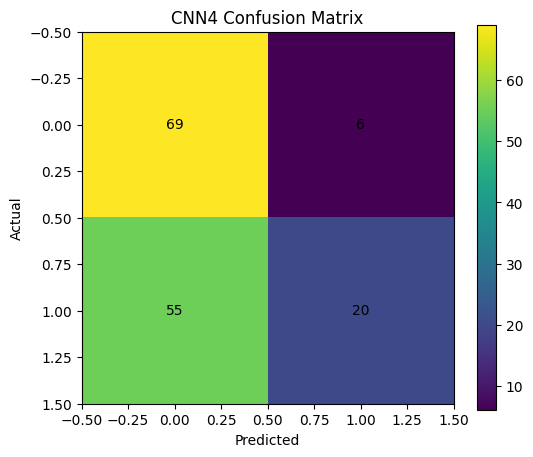

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_4, y_pred_4)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("CNN4 Confusion Matrix")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i,j]),
                 ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**CNN4 Learning Curve**

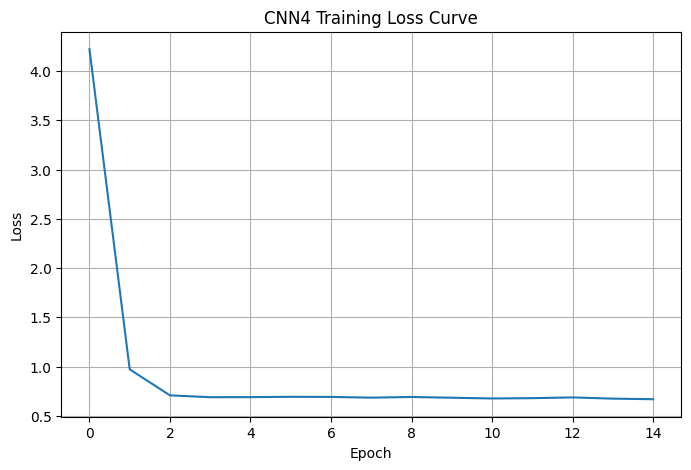

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(cnn4_losses)

plt.title("CNN4 Training Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

**CNN5 Architecture**

In [ ]:
class CNN5(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(256,512,3,padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                512*7*7,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(
                256,
                2
            )
        )

    def forward(self,x):

        x = self.features(x)

        x = self.classifier(x)

        return x

**Create CNN5**

In [ ]:
cnn5 = CNN5().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    cnn5.parameters(),
    lr=0.0005
)

**Train CNN5**

In [ ]:
cnn5_losses = train_model(
    cnn5,
    train_loader,
    optimizer,
    criterion,
    epochs=15
)

Epoch 1/15 Loss: 2.5548
Epoch 2/15 Loss: 0.7994
Epoch 3/15 Loss: 0.7028
Epoch 4/15 Loss: 0.6897
Epoch 5/15 Loss: 0.6921
Epoch 6/15 Loss: 0.6853
Epoch 7/15 Loss: 0.6889
Epoch 8/15 Loss: 0.6863
Epoch 9/15 Loss: 0.6677
Epoch 10/15 Loss: 0.6666
Epoch 11/15 Loss: 0.6820
Epoch 12/15 Loss: 0.6714
Epoch 13/15 Loss: 0.6547
Epoch 14/15 Loss: 0.6749
Epoch 15/15 Loss: 0.6694


**Evaluate CNN5**

In [ ]:
y_true_5, y_pred_5 = evaluate_model(
    cnn5,
    test_loader
)

              precision    recall  f1-score   support

           0       0.59      0.96      0.73        75
           1       0.89      0.33      0.49        75

    accuracy                           0.65       150
   macro avg       0.74      0.65      0.61       150
weighted avg       0.74      0.65      0.61       150

Accuracy: 0.6466666666666666
Precision: 0.8928571428571429
Recall: 0.3333333333333333
F1 Score: 0.4854368932038835


**CNN5 Confusion Matrix**

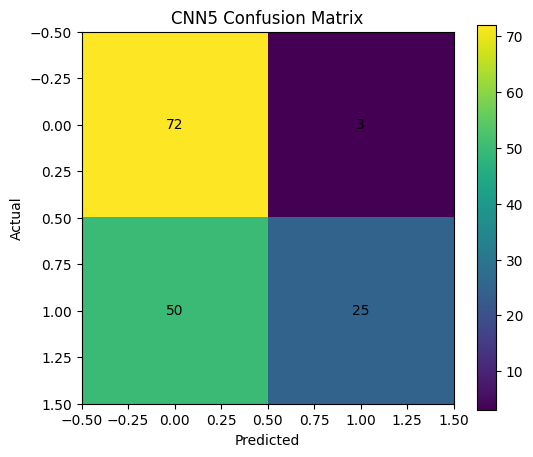

In [ ]:
cm = confusion_matrix(y_true_5, y_pred_5)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("CNN5 Confusion Matrix")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i,j]),
                 ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**CNN5 Learning Curve**

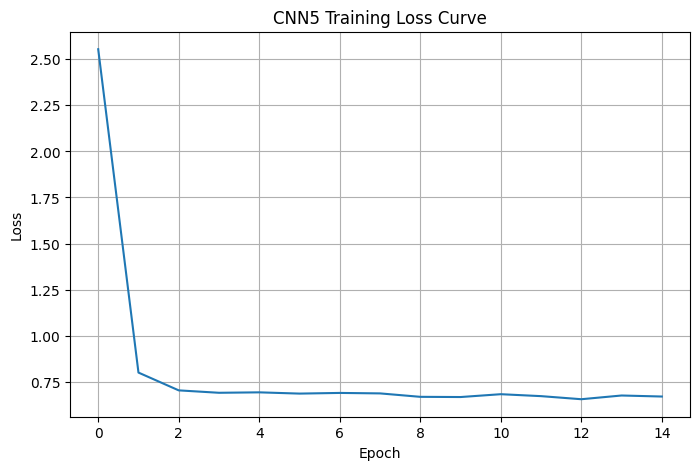

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(cnn5_losses)

plt.title("CNN5 Training Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

**FINAL COMPARISON TABLE**

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["CNN3", "CNN4", "CNN5"],

    "Accuracy": [
        accuracy_score(y_true_3, y_pred_3),
        accuracy_score(y_true_4, y_pred_4),
        accuracy_score(y_true_5, y_pred_5)
    ],

    "Precision": [
        precision_score(y_true_3, y_pred_3),
        precision_score(y_true_4, y_pred_4),
        precision_score(y_true_5, y_pred_5)
    ],

    "Recall": [
        recall_score(y_true_3, y_pred_3),
        recall_score(y_true_4, y_pred_4),
        recall_score(y_true_5, y_pred_5)
    ],

    "F1 Score": [
        f1_score(y_true_3, y_pred_3),
        f1_score(y_true_4, y_pred_4),
        f1_score(y_true_5, y_pred_5)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,CNN3,0.566667,0.727273,0.213333,0.329897
1,CNN4,0.593333,0.769231,0.266667,0.396040
2,CNN5,0.646667,0.892857,0.333333,0.485437


# **TASK 3: Transfer Learning Models**

**Import Pretrained Models**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models

### **MobileNetV2**

**Create Model**

In [ ]:
mobilenet = models.mobilenet_v2(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 98.2MB/s]


**Freeze Layers**

In [ ]:
for param in mobilenet.features.parameters():
    param.requires_grad = False

**Modify Classifier**

In [ ]:
mobilenet.classifier = nn.Sequential(
    nn.Linear(1280, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2)
)

mobilenet = mobilenet.to(device)

**Loss + Optimizer**

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer_mob = optim.Adam(
    mobilenet.classifier.parameters(),
    lr=0.0005
)

**Train MobileNetV2**

In [ ]:
mobilenet_losses = train_model(
    mobilenet,
    train_loader,
    optimizer_mob,
    criterion,
    epochs=10
)

Epoch 1/10 Loss: 0.6189
Epoch 2/10 Loss: 0.5631
Epoch 3/10 Loss: 0.5357
Epoch 4/10 Loss: 0.4955
Epoch 5/10 Loss: 0.4662
Epoch 6/10 Loss: 0.5026
Epoch 7/10 Loss: 0.4570
Epoch 8/10 Loss: 0.4301
Epoch 9/10 Loss: 0.4493
Epoch 10/10 Loss: 0.4328


**Evaluate MobileNetV2**

In [ ]:
y_true_mob, y_pred_mob = evaluate_model(
    mobilenet,
    test_loader
)

              precision    recall  f1-score   support

           0       0.68      0.84      0.75        75
           1       0.79      0.60      0.68        75

    accuracy                           0.72       150
   macro avg       0.73      0.72      0.72       150
weighted avg       0.73      0.72      0.72       150

Accuracy: 0.72
Precision: 0.7894736842105263
Recall: 0.6
F1 Score: 0.6818181818181818


**MobileNetV2's confusion matrix**

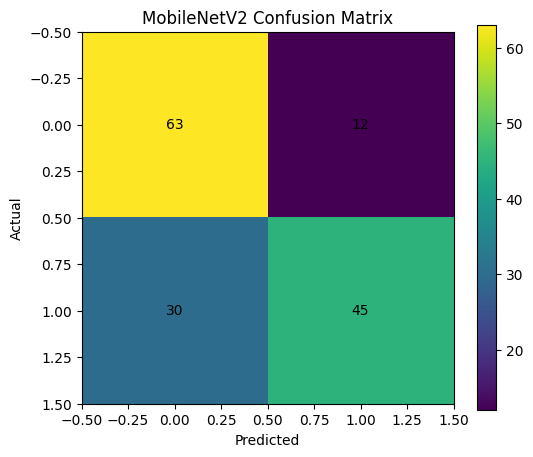

In [ ]:
cm_mob = confusion_matrix(y_true_mob, y_pred_mob)

plt.figure(figsize=(6,5))
plt.imshow(cm_mob)
plt.title("MobileNetV2 Confusion Matrix")
plt.colorbar()

for i in range(cm_mob.shape[0]):
    for j in range(cm_mob.shape[1]):
        plt.text(j, i, str(cm_mob[i,j]),
                 ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**MobileNetV2 learning curve**

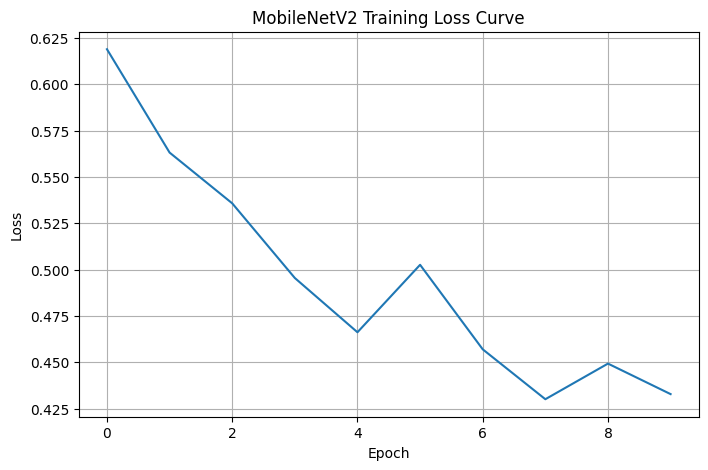

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(mobilenet_losses)

plt.title("MobileNetV2 Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### **ResNet18**

**Load Model**

In [ ]:
resnet = models.resnet18(pretrained=True)

**Freeze Layers**

In [ ]:
for param in resnet.parameters():
    param.requires_grad = False

**Modify Final Layer**

In [ ]:
resnet.fc = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2)
)

resnet = resnet.to(device)

**Optimizer**

In [ ]:
optimizer_res = optim.Adam(
    resnet.fc.parameters(),
    lr=0.0005
)

**Train ReseNet18**

In [ ]:
resnet_losses = train_model(
    resnet,
    train_loader,
    optimizer_res,
    criterion,
    epochs=10
)

Epoch 1/10 Loss: 0.6562
Epoch 2/10 Loss: 0.5533
Epoch 3/10 Loss: 0.5281
Epoch 4/10 Loss: 0.5007
Epoch 5/10 Loss: 0.4946
Epoch 6/10 Loss: 0.4886
Epoch 7/10 Loss: 0.4787
Epoch 8/10 Loss: 0.5336
Epoch 9/10 Loss: 0.4937
Epoch 10/10 Loss: 0.4692


**Evaluate ResNet18**

In [ ]:
y_true_res, y_pred_res = evaluate_model(
    resnet,
    test_loader
)

              precision    recall  f1-score   support

           0       0.71      0.95      0.81        75
           1       0.92      0.61      0.74        75

    accuracy                           0.78       150
   macro avg       0.81      0.78      0.77       150
weighted avg       0.81      0.78      0.77       150

Accuracy: 0.78
Precision: 0.92
Recall: 0.6133333333333333
F1 Score: 0.736


**ResNet18 confusion matrix**

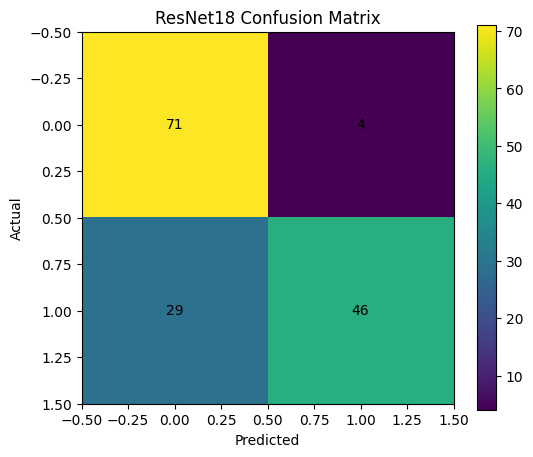

In [ ]:
cm_res = confusion_matrix(y_true_res, y_pred_res)

plt.figure(figsize=(6,5))
plt.imshow(cm_res)
plt.title("ResNet18 Confusion Matrix")
plt.colorbar()

for i in range(cm_res.shape[0]):
    for j in range(cm_res.shape[1]):
        plt.text(j, i, str(cm_res[i,j]),
                 ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**ResNet18 Learning Curve**

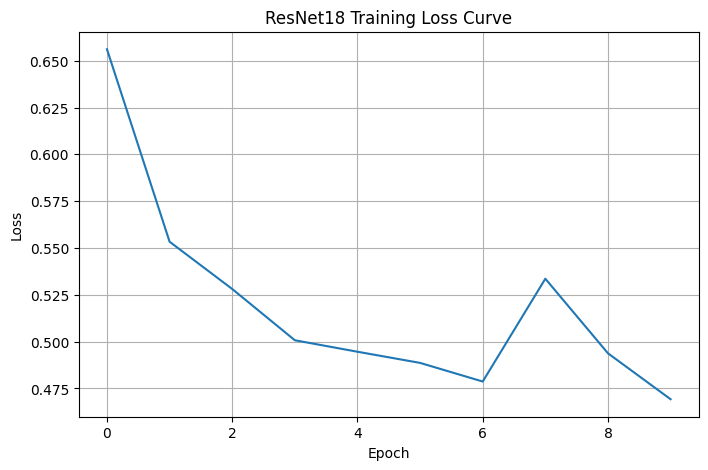

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(resnet_losses)

plt.title("ResNet18 Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)
plt.show()

### **SqueezeNet**

**Load Model**

In [ ]:
squeezenet = models.squeezenet1_0(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_0_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/squeezenet1_0-b66bff10.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_0-b66bff10.pth


100%|██████████| 4.78M/4.78M [00:00<00:00, 26.3MB/s]


**Modify Classifier**

In [ ]:
squeezenet.classifier[1] = nn.Conv2d(512, 2, kernel_size=1)
squeezenet.num_classes = 2

squeezenet = squeezenet.to(device)

**Optimizer**

In [ ]:
optimizer_sq = optim.Adam(
    squeezenet.parameters(),
    lr=0.0005
)

**Train SqueezeNet**

In [ ]:
squeeze_losses = train_model(
    squeezenet,
    train_loader,
    optimizer_sq,
    criterion,
    epochs=10
)

Epoch 1/10 Loss: 0.7163
Epoch 2/10 Loss: 0.6886
Epoch 3/10 Loss: 0.6914
Epoch 4/10 Loss: 0.6883
Epoch 5/10 Loss: 0.6794
Epoch 6/10 Loss: 0.6585
Epoch 7/10 Loss: 0.6413
Epoch 8/10 Loss: 0.6511
Epoch 9/10 Loss: 0.6259
Epoch 10/10 Loss: 0.6919


**Evaluate SqueezeNet**

In [ ]:
y_true_sq, y_pred_sq = evaluate_model(
    squeezenet,
    test_loader
)

              precision    recall  f1-score   support

           0       0.54      0.97      0.70        75
           1       0.87      0.17      0.29        75

    accuracy                           0.57       150
   macro avg       0.70      0.57      0.49       150
weighted avg       0.70      0.57      0.49       150

Accuracy: 0.5733333333333334
Precision: 0.8666666666666667
Recall: 0.17333333333333334
F1 Score: 0.28888888888888886


**Comparison Table**

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": ["CNN3", "CNN4", "CNN5", "MobileNetV2", "ResNet18", "SqueezeNet"],

    "Accuracy": [
        accuracy_score(y_true_3, y_pred_3),
        accuracy_score(y_true_4, y_pred_4),
        accuracy_score(y_true_5, y_pred_5),
        accuracy_score(y_true_mob, y_pred_mob),
        accuracy_score(y_true_res, y_pred_res),
        accuracy_score(y_true_sq, y_pred_sq),
    ],

    "Precision": [
        precision_score(y_true_3, y_pred_3),
        precision_score(y_true_4, y_pred_4),
        precision_score(y_true_5, y_pred_5),
        precision_score(y_true_mob, y_pred_mob),
        precision_score(y_true_res, y_pred_res),
        precision_score(y_true_sq, y_pred_sq),
    ],

    "Recall": [
        recall_score(y_true_3, y_pred_3),
        recall_score(y_true_4, y_pred_4),
        recall_score(y_true_5, y_pred_5),
        recall_score(y_true_mob, y_pred_mob),
        recall_score(y_true_res, y_pred_res),
        recall_score(y_true_sq, y_pred_sq),
    ],

    "F1 Score": [
        f1_score(y_true_3, y_pred_3),
        f1_score(y_true_4, y_pred_4),
        f1_score(y_true_5, y_pred_5),
        f1_score(y_true_mob, y_pred_mob),
        f1_score(y_true_res, y_pred_res),
        f1_score(y_true_sq, y_pred_sq),
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,CNN3,0.566667,0.727273,0.213333,0.329897
1,CNN4,0.593333,0.769231,0.266667,0.396040
2,CNN5,0.646667,0.892857,0.333333,0.485437
3,MobileNetV2,0.720000,0.789474,0.600000,0.681818
4,ResNet18,0.780000,0.920000,0.613333,0.736000
5,SqueezeNet,0.573333,0.866667,0.173333,0.288889


# **TASK 4 : XAI FOR 1 CUSTOM + 1 PRETRAINED MODEL**

**Install Grad-CAM**

In [ ]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 33.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


**Imports**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

**Select a Test Image**

True Label: 0


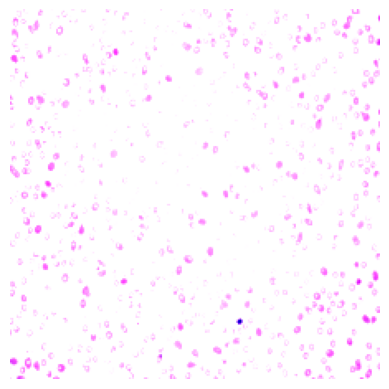

In [ ]:
sample_img, sample_label = test_dataset[0]

print("True Label:", sample_label)

plt.imshow(sample_img.permute(1,2,0))
plt.axis("off")
plt.show()

### **Grad-CAM for CNN5**

**target layer**

In [ ]:
target_layer = cnn5.features[-3]

**Generate Heatmap**

In [ ]:
input_tensor = sample_img.unsqueeze(0).to(device)

cam = GradCAM(
    model=cnn5,
    target_layers=[target_layer]
)

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=None
)

grayscale_cam = grayscale_cam[0]

**Display Result**

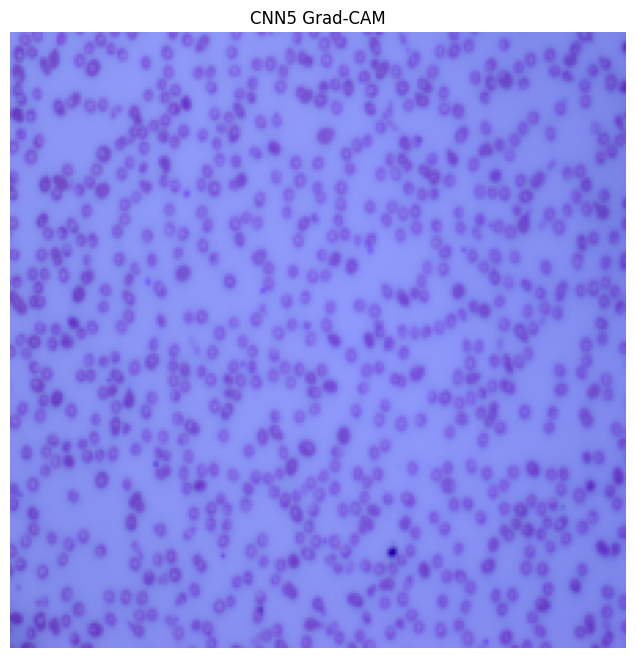

In [ ]:
img_np = sample_img.permute(1,2,0).cpu().numpy()

img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

visualization = show_cam_on_image(
    img_np,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8,8))
plt.imshow(visualization)
plt.title("CNN5 Grad-CAM")
plt.axis("off")
plt.show()

**CNN5 Grad-CAM Interpretation**

The Grad-CAM visualization highlights the regions that contributed most to the prediction. CNN5 focuses primarily on red blood cell areas and morphological patterns rather than background pixels. This indicates that the model has learned relevant visual features associated with anemia classification.

### **Grad-CAM for ResNet18**

**Target Layer**

In [ ]:
target_layer = resnet.layer4[-1].conv2

In [ ]:
resnet.eval()
for p in resnet.parameters():
    p.requires_grad = True

**Generate Heatmap**

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ensure model is ready
resnet.eval()
for p in resnet.parameters():
    p.requires_grad = True

target_layer = resnet.layer4[-1].conv2

input_tensor = sample_img.unsqueeze(0).to(device)

# prediction
output = resnet(input_tensor)
pred_class = output.argmax(dim=1).item()

targets = [ClassifierOutputTarget(pred_class)]

cam = GradCAM(
    model=resnet,
    target_layers=[target_layer]
)

# IMPORTANT FIX: enable gradient flow explicitly
with torch.enable_grad():
    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )

grayscale_cam = grayscale_cam[0]

**Display Result**

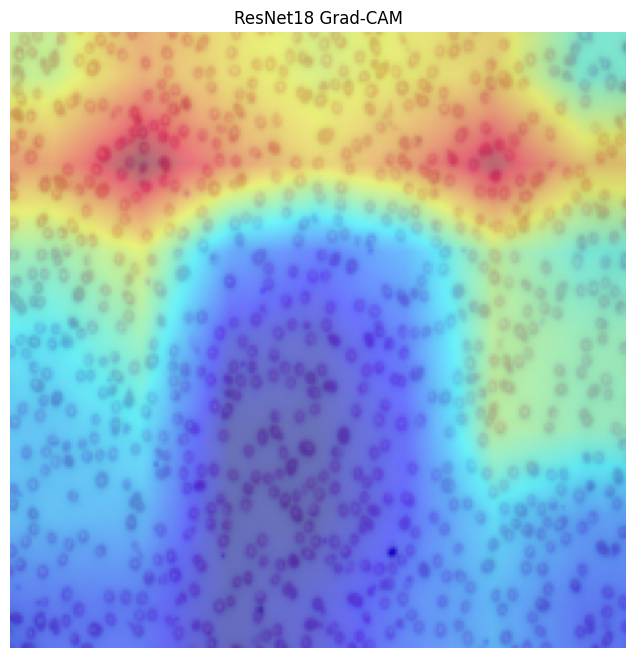

In [ ]:
img_np = sample_img.permute(1,2,0).cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

visualization = show_cam_on_image(
    img_np,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8,8))
plt.imshow(visualization)
plt.title("ResNet18 Grad-CAM")
plt.axis("off")
plt.show()

**ResNet18 Grad-CAM Interpretation**

The ResNet18 Grad-CAM heatmap shows more concentrated attention around individual red blood cells and cell boundaries. Compared to CNN5, the activation regions are more focused, suggesting stronger feature extraction capabilities. This observation is consistent with the higher classification accuracy achieved by ResNet18.

## **Comparison of Explainability Results**

Both CNN5 and ResNet18 focus on red blood cell regions when making predictions. However, ResNet18 produces more concentrated activation maps and attends to finer cell structures. The improved localization capability may explain why ResNet18 achieved the highest accuracy (78%) and F1-score (0.736) among all evaluated models.